In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Elo ratings analysis

1️⃣ Does the calculation method ever change?

The core Elo formula has remained structurally consistent:

R
new
	​

=R
old
	​

+K⋅(W−W
e
	​

)

Where:

R = rating
K = match importance factor
W = actual result (1, 0.5, 0)
W
e
	​

 = expected result (logistic function of rating difference)

However, while the formula framework stayed stable, parameterization and contextual rules have been adjusted over time, including:

Tournament importance multipliers (K-factor adjustments)
Goal difference scaling rules
Home-field advantage constant
Treatment of penalty shootouts
Initial ratings for new teams

So:
✔ Core math → stable
✔ Implementation details → occasionally refined

2️⃣ Were there changes between 2010–2026?

There were no fundamental mathematical overhauls, but several incremental refinements occurred:

A. Match Importance (K-Factor Adjustments)

Tournament weights were fine-tuned over time. For example:

World Cup finals matches receive the highest K
Continental tournaments slightly below
Qualifiers and friendlies progressively lower

Post-2014 and post-2018 cycles saw small calibration adjustments.

B. Goal Difference Scaling

Elo applies a goal-difference multiplier:

1 goal → standard
2 goals → slightly amplified
3+ goals → logarithmic scaling

The scaling logic remained consistent but was occasionally recalibrated to reduce blowout distortion.

C. Home Advantage Parameter

The fixed home-field boost (typically around +100 Elo points equivalent) has been reviewed periodically to reflect modern football trends, especially:

Neutral venues
Pandemic-era matches (2020–2021) with no crowds

This is the most practically relevant adjustment in 2010–2026.

D. COVID Impact (2020–2022)

Not a formula change, but:

Fewer matches
Neutral venues
Reduced home advantage effect

This indirectly altered rating dynamics.

3️⃣ Important Distinction

Do not confuse:

World Football Elo Ratings (independent system)
with
FIFA Rankings

FIFA changed its ranking formula significantly in 2018 (to an Elo-based system).
World Football Elo Ratings did not undergo a comparable structural overhaul in that period.

4️⃣ Practical Implication for Your Modeling

If you're using Elo data from 2010–2026:

It is methodologically consistent enough for longitudinal modeling.
Minor parameter tweaks will not invalidate time-series modeling.
If precision is critical (e.g., simulation modeling), check:
Whether you're using snapshot data or recomputed ratings
If home advantage constant is fixed across your dataset
5️⃣ Bottom Line

Between 2010 and 2026:

No major formula change
Some parameter refinements
Pandemic period temporarily affected rating behavior
Overall system remains comparable across years

In [42]:
"""
Feature engineering: rebuild the columns that exist in train.csv but are missing from test.csv.

Strategy: since train and test are a temporal split (train ≤ 2011-08-04, test ≥ 2011-08-06),
all rolling/form/Elo/H2H/rest features are just functions of prior match history.
With the ground-truth scores reconstructed for test rows, we can rebuild every missing column
using the SAME recipe the organiser used, computed chronologically with shift(1) to
guarantee no look-ahead leak.

Features reconstructed:
  - team_points_last5, opp_points_last5, team_points_last10, opp_points_last10
  - team_gd_last5, opp_gd_last5
  - team_avg_goals_last5, team_avg_conceded_last5
  - opp_avg_goals_last5, opp_avg_conceded_last5
  - team_win_rate_last10, opp_win_rate_last10
  - h2h_points_last5, h2h_gd_last5
  - days_since_last_match_team, days_since_last_match_opp
  - points_last5_diff, gd_last5_diff
  - elo_team, elo_opponent                   (chronological Elo)
  - tournament_importance                    (new engineered feature)

NOT reconstructed (needs external FIFA rank data):
  - rank_team, rank_opponent, rank_diff, rank_missing_team, rank_missing_opp
  You can either scrape FIFA rankings, or drop these columns from both train/test for modelling.
"""

import numpy as np
import pandas as pd


# ────────────────────────────────────────────────────────────────────────────
# 1. Tournament importance  (engineered feature replacing/complementing rank)
# ────────────────────────────────────────────────────────────────────────────
def assign_tournament_importance(name: str) -> int:
    """
    Map tournament name → importance 1–5, inspired by FIFA's match-weight scheme.
      1: Friendly
      2: Minor regional / Island / invitational
      3: Qualifier (WC, continental) / Nations League
      4: Continental final tournament (Euro, Copa, AFCON, Asian Cup, Gold Cup, etc.)
      5: FIFA World Cup (main tournament)
    """
    if not isinstance(name, str) or name.strip() == "":
        return 1
    n = name.lower()

    # Tier 5 — the World Cup itself
    if "fifa world cup" in n and "qualif" not in n:
        return 5

    # Tier 4 — continental final tournaments & Confederations Cup
    tier4_keys = [
        "uefa euro", "copa américa", "copa america", "african cup of nations",
        "afc asian cup", "gold cup", "concacaf championship", "concacaf gold",
        "ofc nations cup", "oceania nations cup", "confederations cup",
        "africa cup of nations", "copa libertadores",
    ]
    if any(k in n for k in tier4_keys) and "qualif" not in n:
        return 4

    # Tier 3 — qualifiers + Nations League + major intercontinental tournaments
    if "qualif" in n:
        return 3
    if "nations league" in n:
        return 3
    if "olympic" in n:
        return 3  # Olympic football is prestigious but not FIFA-A status
    if "confederations" in n:
        return 3

    # Tier 2 — minor regional cups (CECAFA, COSAFA, CFU, Gulf Cup, AFF, SEA Games, etc.)
    tier2_keys = [
        "cecafa", "cosafa", "cfu caribbean", "gulf cup", "aff championship",
        "southeast asian", "king's cup", "merdeka", "island games",
        "asian games", "south asian", "baltic cup", "nordic championship",
        "british home championship", "algarve cup", "cyprus cup",
        "shebelieves", "tournament", "cup",
    ]
    if any(k in n for k in tier2_keys):
        return 2

    # Tier 1 — friendlies, kings/queens-cup style exhibitions, unknown
    if "friendly" in n:
        return 1
    return 1  # unknown → assume friendly-level


# ────────────────────────────────────────────────────────────────────────────
# 2. Unified match history (train + test with reconstructed ground truth)
# ────────────────────────────────────────────────────────────────────────────
def build_unified_history(train_path: str,
                          test_path: str,
                          test_truth_path: str) -> pd.DataFrame:
    """Combine train rows and test rows (with their reconstructed targets)
    into a single chronological, per-team-perspective DataFrame."""
    keep = ["Id", "match_id", "date", "gender", "team", "opponent",
            "is_home", "neutral", "tournament", "team_goals", "opp_goals"]

    tr = pd.read_csv(train_path, usecols=keep)
    te_feat = pd.read_csv(test_path)
    te_tgt = pd.read_csv(test_truth_path, usecols=["Id", "team_goals", "opp_goals"])
    te = te_feat.merge(te_tgt, on="Id", how="left")

    tr = tr.assign(split="train")
    te = te[keep].assign(split="test")

    df = pd.concat([tr, te], ignore_index=True)
    df["date"] = pd.to_datetime(df["date"])
    # Stable chronological order — two rows of same match stay adjacent
    df = df.sort_values(["date", "match_id", "is_home"],
                        ascending=[True, True, False]).reset_index(drop=True)
    return df


# ────────────────────────────────────────────────────────────────────────────
# 3. Rolling per-team features
# ────────────────────────────────────────────────────────────────────────────
def _match_outcome_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Compute per-row outcome (points, GD, win/draw flag) from this-match scores."""
    df = df.copy()
    tg = df["team_goals"].astype("float")
    og = df["opp_goals"].astype("float")
    df["_points"] = np.where(tg > og, 3, np.where(tg == og, 1, 0))
    df["_gd"] = tg - og
    df["_win"] = (tg > og).astype(float)
    return df


def add_rolling_team_features(df: pd.DataFrame) -> pd.DataFrame:
    """Rolling form features from the TEAM's perspective.  Uses shift(1) to
    guarantee the window covers only matches BEFORE the current row."""
    df = _match_outcome_cols(df)

    def lag_roll(col, window, op):
        # transform returns a Series aligned with the original index
        return df.groupby("team", sort=False)[col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=1).agg(op))

    df["team_points_last5"]       = lag_roll("_points", 5,  "sum")
    df["team_points_last10"]      = lag_roll("_points", 10, "sum")
    df["team_gd_last5"]           = lag_roll("_gd",     5,  "sum")
    df["team_avg_goals_last5"]    = lag_roll("team_goals", 5, "mean")
    df["team_avg_conceded_last5"] = lag_roll("opp_goals",  5, "mean")
    df["team_win_rate_last10"]    = lag_roll("_win",    10, "mean")
    df["days_since_last_match_team"] = df.groupby("team", sort=False)["date"].transform(
        lambda s: (s - s.shift(1)).dt.days)
    return df


def add_opponent_side_features(df: pd.DataFrame) -> pd.DataFrame:
    """Mirror team_* features onto opp_* columns via self-merge on match_id.
    For each match there are two rows (team↔opp swapped); the 'team_*' of the
    mirror row IS the 'opp_*' we want."""
    cols_pairs = [
        ("team_points_last5",       "opp_points_last5"),
        ("team_points_last10",      "opp_points_last10"),
        ("team_gd_last5",           "opp_gd_last5"),
        ("team_avg_goals_last5",    "opp_avg_goals_last5"),
        ("team_avg_conceded_last5", "opp_avg_conceded_last5"),
        ("team_win_rate_last10",    "opp_win_rate_last10"),
        ("days_since_last_match_team", "days_since_last_match_opp"),
    ]
    src = ["match_id", "team"] + [c[0] for c in cols_pairs]
    mirror = df[src].rename(columns={"team": "opponent",
                                     **{c[0]: c[1] for c in cols_pairs}})
    return df.merge(mirror, on=["match_id", "opponent"], how="left")


def add_diff_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["points_last5_diff"] = df["team_points_last5"] - df["opp_points_last5"]
    df["gd_last5_diff"]     = df["team_gd_last5"]     - df["opp_gd_last5"]
    return df


# ────────────────────────────────────────────────────────────────────────────
# 4. Head-to-head features
# ────────────────────────────────────────────────────────────────────────────
def add_h2h_features(df: pd.DataFrame) -> pd.DataFrame:
    """H2H is directional from team's perspective: past matches between
    exactly these two teams, team's points & GD."""
    df = df.copy()
    g = df.groupby(["team", "opponent"], sort=False)
    df["h2h_points_last5"] = g["_points"].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).sum())
    df["h2h_gd_last5"] = g["_gd"].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).sum())
    return df


# ────────────────────────────────────────────────────────────────────────────
# 5. Elo ratings — World Football Elo Ratings formula (Wikipedia spec)
#    https://en.wikipedia.org/wiki/World_Football_Elo_Ratings
# ────────────────────────────────────────────────────────────────────────────
def _elo_match_weight_K(tournament: str, match_date) -> int:
    """Tournament weight K per Wikipedia spec.

       World Cup, Olympic Games (1908–1980)            →  60
       Continental & intercontinental championships    →  50
       WC/Continental qualifiers & major tournaments   →  40
       All other tournaments                           →  30
       Friendly matches                                →  20
    """
    if not isinstance(tournament, str):
        return 30
    n = tournament.lower()

    # Olympic Games: K=60 only for 1908-1980 (amateur era); after 1980 it
    # became U-23 and drops to "all other tournaments" (K=30).
    if "olympic" in n:
        year = pd.Timestamp(match_date).year
        return 60 if 1908 <= year <= 1980 else 30

    # K=60: FIFA World Cup (main tournament, not qualifiers)
    if "fifa world cup" in n and "qualif" not in n:
        return 60

    # K=50: Continental championships (final tournament) + intercontinental
    tier50_keys = [
        "uefa euro", "copa américa", "copa america",
        "african cup of nations", "africa cup of nations",
        "afc asian cup", "gold cup", "concacaf championship",
        "ofc nations cup", "oceania nations cup",
        "confederations cup",
    ]
    if any(k in n for k in tier50_keys) and "qualif" not in n:
        return 50

    # K=40: any qualifier + "major tournaments" (continental Nations Leagues)
    if "qualif" in n:
        return 40
    if "nations league" in n:
        return 40  # UEFA / CONCACAF / CAF Nations League — a "major tournament"

    # K=20: friendlies
    if "friendly" in n:
        return 20

    # K=30: all other tournaments (regional cups, invitationals, etc.)
    return 30


def _elo_goal_diff_multiplier(gd: int) -> float:
    """G factor per Wikipedia:
         GD 0 or 1 →  G = 1
         GD 2      →  G = 1.5
         GD N ≥ 3  →  G = (11 + N) / 8
       Examples: gd=3 → 1.75, gd=4 → 1.875, gd=5 → 2.0, gd=10 → 2.625.
    """
    gd = int(abs(gd))
    if gd <= 1:
        return 1.0
    if gd == 2:
        return 1.5
    return (11.0 + gd) / 8.0


def add_elo_features(df: pd.DataFrame,
                     initial: float = 1500.0,
                     home_adv: float = 100.0) -> pd.DataFrame:
    """World Football Elo Ratings (eloratings.net methodology per Wikipedia).

       Formula:   P  = K · G · (W − We)                      (rounded to nearest int)
                  We = 1 / (10^(−dr/400) + 1)
                  dr = R_team − R_opp + HA
                  HA = +100 for team-home, −100 for team-away, 0 for neutral
                  K  = tournament weight {20, 30, 40, 50, 60}
                  G  = goal-difference multiplier (Wikipedia table)
                  W  = 1 win / 0.5 draw / 0 loss
                       (penalty-shootout results already encoded as draws in results.csv)

       Rating tracked SEPARATELY per gender (M and W have no team overlap).
       Pre-match ratings are recorded for both perspectives of each match and
       merged back onto every row of df.
    """
    df = df.copy()
    df["elo_team"] = np.nan
    df["elo_opponent"] = np.nan

    elo_per_gender = {"M": {}, "W": {}}  # gender -> {team_name: rating}
    pre_elo: dict[tuple, float] = {}     # (match_id, team_name) -> pre-match rating

    # Iterate one row per match in chronological order; prefer the home-team
    # perspective so that home_adv sign convention stays simple.
    first_rows = df.drop_duplicates("match_id", keep="first").sort_values(
        ["date", "match_id"]).reset_index(drop=True)

    for row in first_rows.itertuples(index=False):
        g = row.gender
        elo = elo_per_gender.get(g)
        if elo is None:
            continue

        R_team = elo.get(row.team,     initial)
        R_opp  = elo.get(row.opponent, initial)

        # Record pre-match Elo for BOTH perspectives of this match
        pre_elo[(row.match_id, row.team)]     = R_team
        pre_elo[(row.match_id, row.opponent)] = R_opp

        # Skip update if scores unknown
        tg, og = row.team_goals, row.opp_goals
        if pd.isna(tg) or pd.isna(og):
            continue
        tg, og = int(tg), int(og)

        # Home-advantage sign (from team's perspective)
        if row.neutral:
            HA = 0.0
        elif row.is_home == 1:
            HA = +home_adv
        else:
            HA = -home_adv

        # Expected result
        dr = R_team - R_opp + HA
        We = 1.0 / (10 ** (-dr / 400.0) + 1.0)

        # Actual result (penalty shootouts are encoded as draws via equal scores)
        if tg > og:   W = 1.0
        elif tg < og: W = 0.0
        else:         W = 0.5

        # Tournament weight and goal-difference multiplier
        K = _elo_match_weight_K(row.tournament, row.date)
        G = _elo_goal_diff_multiplier(tg - og)

        # Points change (rounded to nearest integer per spec)
        P = round(K * G * (W - We))

        elo[row.team]     = R_team + P
        elo[row.opponent] = R_opp  - P

    # Map back onto every df row (both perspectives of every match)
    df["elo_team"]     = df.apply(lambda r: pre_elo.get((r["match_id"], r["team"]),     np.nan), axis=1)
    df["elo_opponent"] = df.apply(lambda r: pre_elo.get((r["match_id"], r["opponent"]), np.nan), axis=1)
    return df


# ────────────────────────────────────────────────────────────────────────────
# 6. Main orchestrator
# ────────────────────────────────────────────────────────────────────────────
def build_all_features(df: pd.DataFrame,
                       elo_home_adv: float = 100.0,
                       elo_initial: float = 1500.0) -> pd.DataFrame:
    """Add every reconstructable feature column in the right order."""
    print(f"  [features] starting with {len(df):,} rows")
    df = add_rolling_team_features(df)
    print("  [features] team rolling done")
    df = add_opponent_side_features(df)
    print("  [features] opponent mirror done")
    df = add_diff_features(df)
    df = add_h2h_features(df)
    print("  [features] h2h done")
    df = add_elo_features(df, home_adv=elo_home_adv, initial=elo_initial)
    print("  [features] elo done (World Football Elo Ratings spec)")
    df["tournament_importance"] = df["tournament"].map(assign_tournament_importance)
    # drop helper cols
    df = df.drop(columns=[c for c in ["_points", "_gd", "_win"] if c in df.columns])
    print(f"  [features] finished: {df.shape[1]} columns")
    return df


if __name__ == "__main__":
    # Smoke test
    from pathlib import Path
    BASE = "./"
    df = build_unified_history(
        "./data/train.csv",
        "./data/test.csv",
        "./data/test_with_groundtruth.csv",
    )
    out = build_all_features(df)
    print(out[["date", "team", "opponent", "elo_team", "elo_opponent",
               "team_points_last5", "tournament_importance"]].head(10))

  [features] starting with 121,194 rows
  [features] team rolling done
  [features] opponent mirror done
  [features] h2h done
  [features] elo done (World Football Elo Ratings spec)
  [features] finished: 33 columns
        date      team  opponent  elo_team  elo_opponent  team_points_last5  \
0 1872-11-30  Scotland   England    1500.0        1500.0                NaN   
1 1872-11-30   England  Scotland    1500.0        1500.0                NaN   
2 1873-03-08   England  Scotland    1503.0        1497.0                1.0   
3 1873-03-08  Scotland   England    1497.0        1503.0                1.0   
4 1874-03-07  Scotland   England    1486.0        1514.0                1.0   
5 1874-03-07   England  Scotland    1514.0        1486.0                4.0   
6 1875-03-06   England  Scotland    1506.0        1494.0                4.0   
7 1875-03-06  Scotland   England    1494.0        1506.0                4.0   
8 1876-03-04  Scotland   England    1497.0        1503.0                

In [47]:
train = pd.read_csv('data/train.csv')
train[['elo_team']]

,elo_team
0,1500.000000
1,1500.000000
2,1500.000000
3,1484.000000
4,1484.000000
...,...
78767,1380.083982
78768,1251.949952
78769,1245.554493
78770,1272.295814


In [49]:
out.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121194 entries, 0 to 121193
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Id                          121194 non-null  object        
 1   match_id                    121194 non-null  object        
 2   date                        121194 non-null  datetime64[ns]
 3   gender                      121194 non-null  object        
 4   team                        121194 non-null  object        
 5   opponent                    121194 non-null  object        
 6   is_home                     121194 non-null  int64         
 7   neutral                     121194 non-null  int64         
 8   tournament                  121194 non-null  object        
 9   team_goals                  121194 non-null  int64         
 10  opp_goals                   121194 non-null  int64         
 11  split                       121194 non-

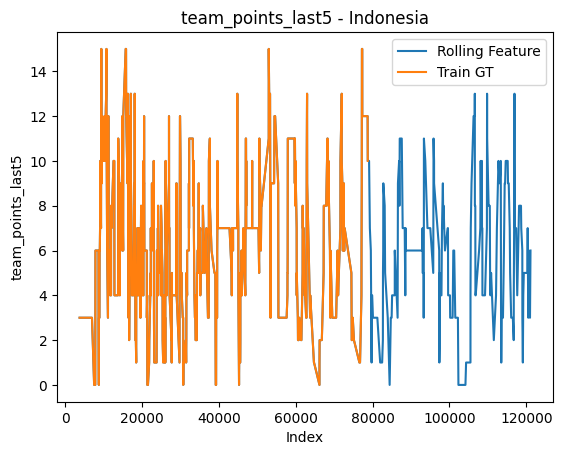

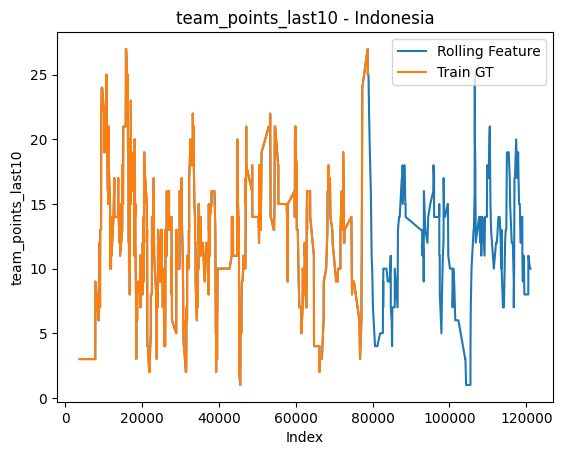

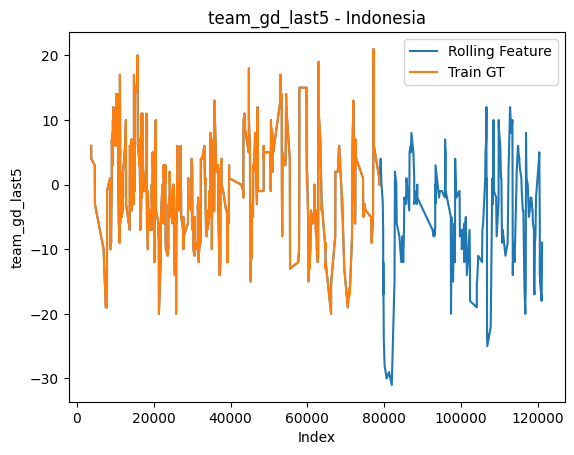

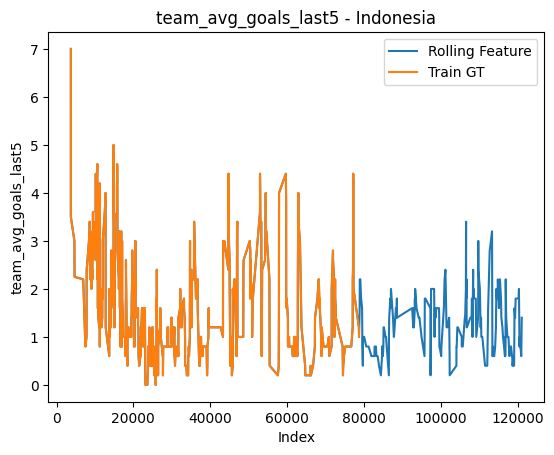

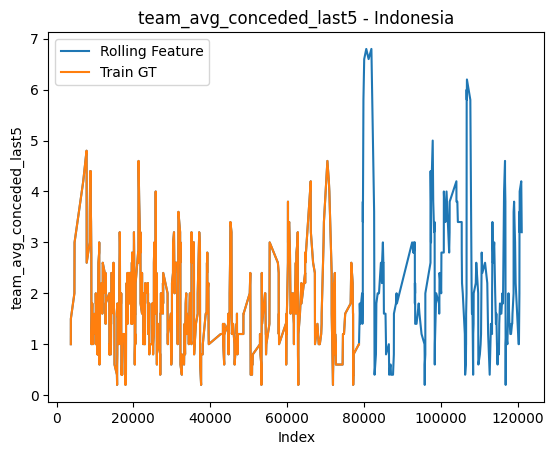

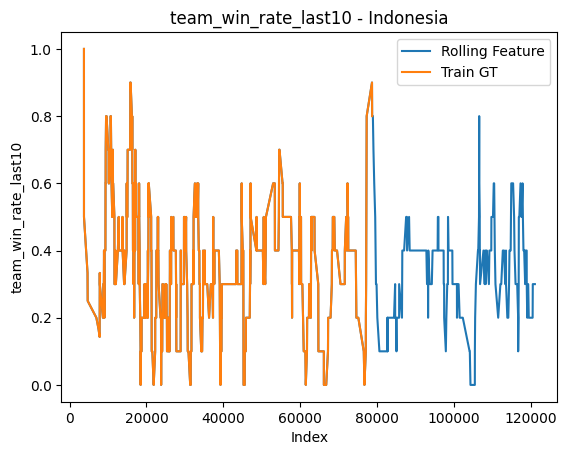

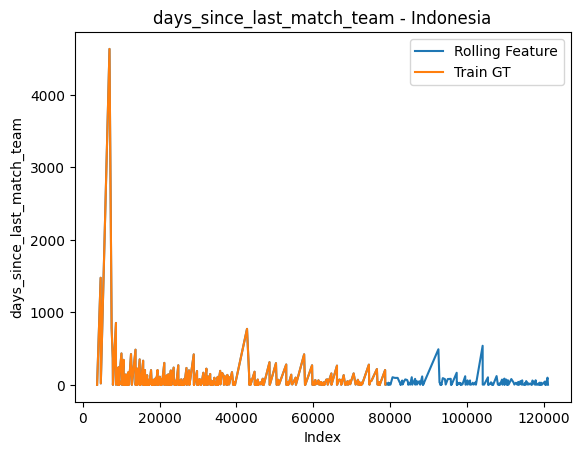

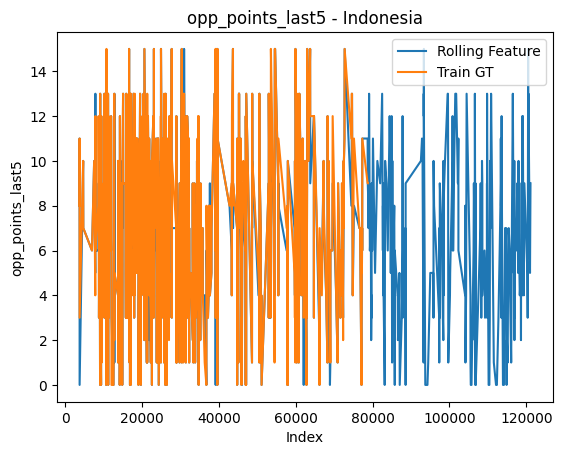

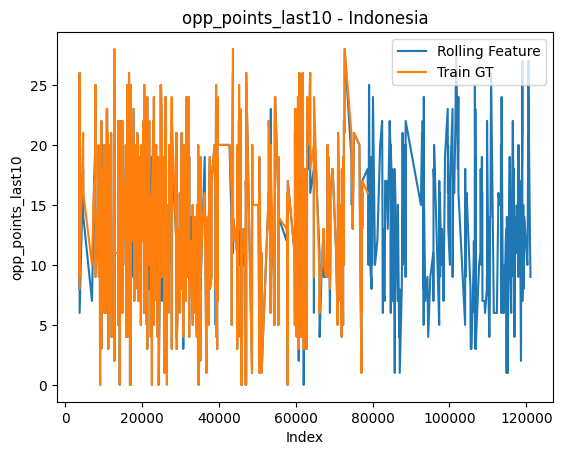

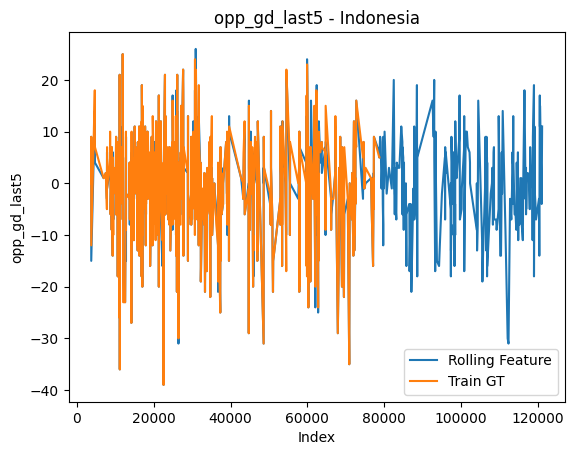

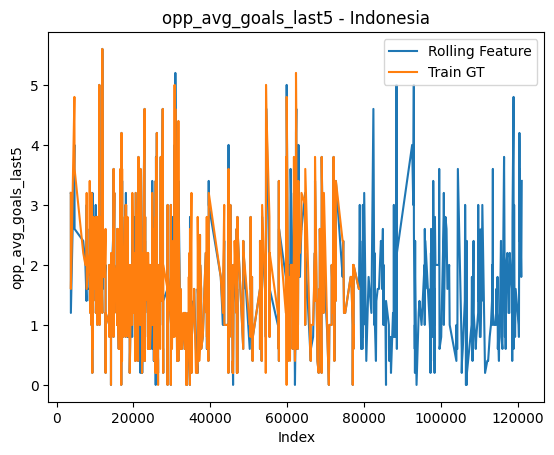

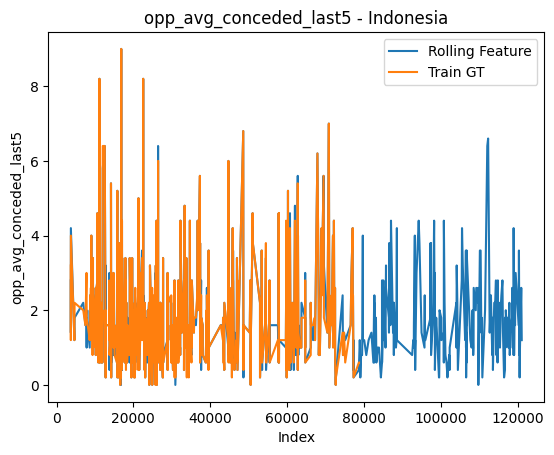

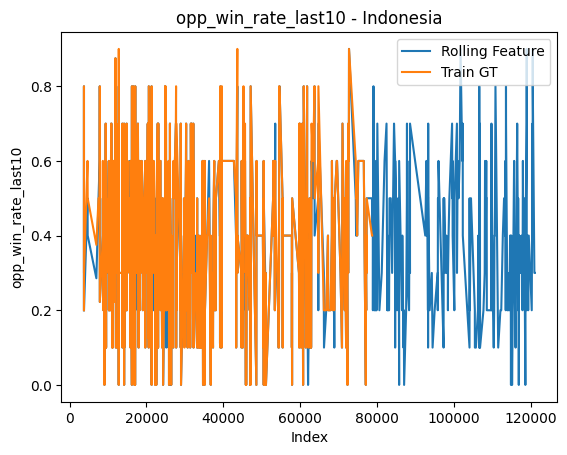

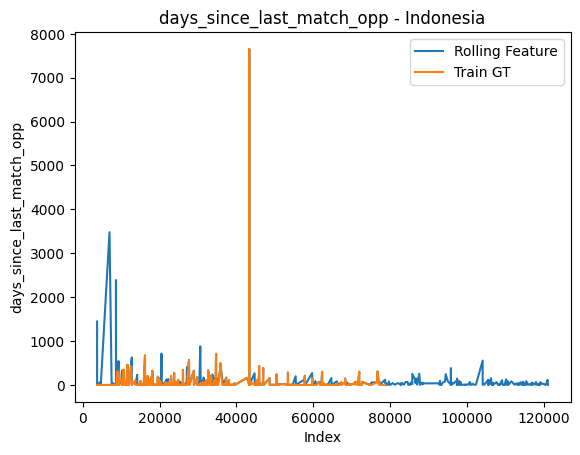

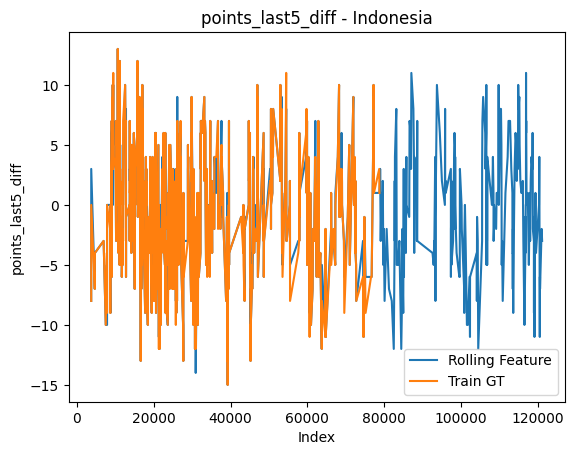

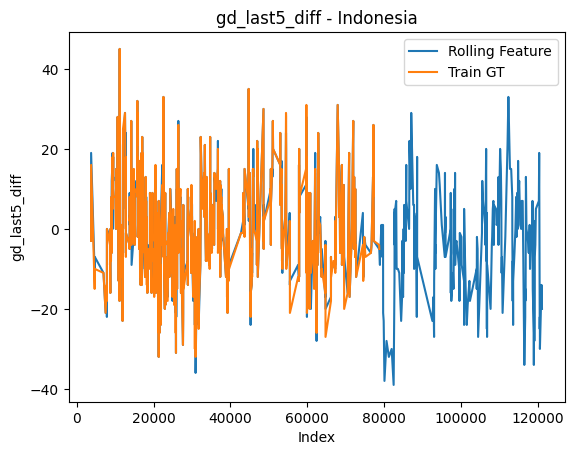

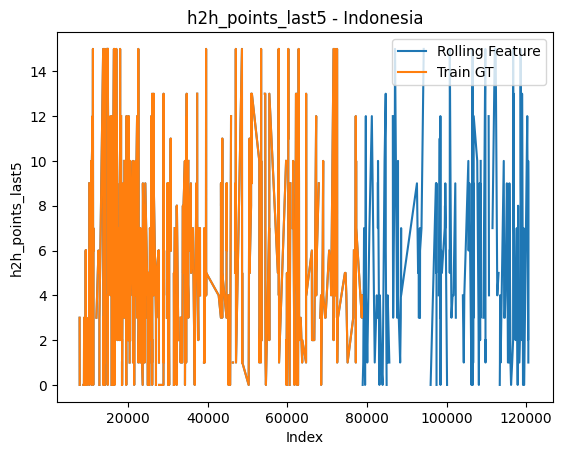

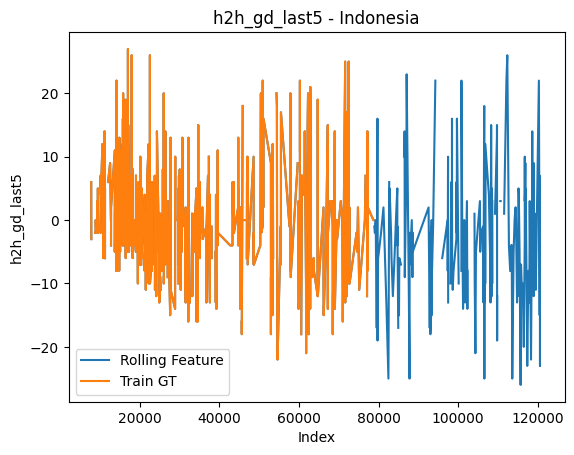

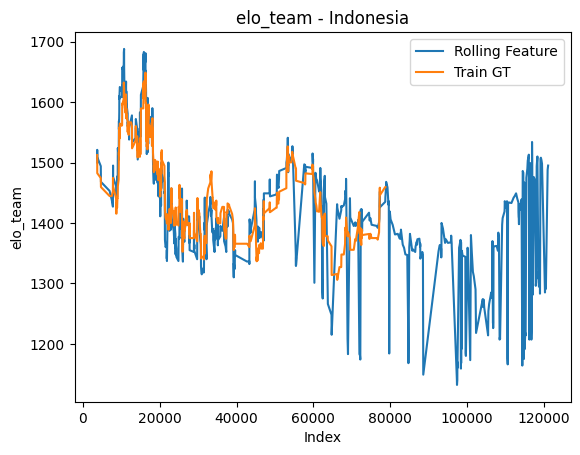

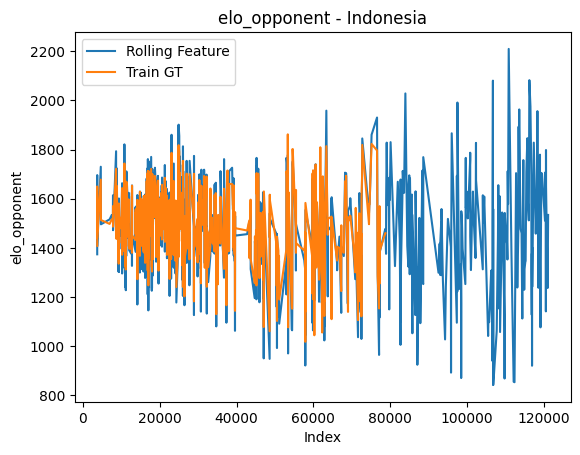

In [51]:
keep = ["Id", "match_id", "date", "gender", "team", "opponent",
            "is_home", "neutral", "tournament", "team_goals", "opp_goals", 'tournament_importance']

country = "Indonesia"
features = out.drop(columns=keep).select_dtypes(include=['number']).columns

for feature in features:
    fig, ax = plt.subplots()

    out[out['team'] == country][feature].plot(ax=ax, label='Rolling Feature')
    train[train['team'] == country][feature].plot(ax=ax, label='Train GT')

    ax.set_title(f"{feature} - {country}")
    ax.set_xlabel("Index")
    ax.set_ylabel(feature)
    ax.legend()

    plt.show()

opp_point_last5
opp_point_last10
opp_gd_last5
opp_avg_goals_last5
opp_conceded_last5
opp_winrate_last5
day_since_last_matchup5
point_last5_diff
gd_last5_diff
elo_team
elo_opponent

not accuracte calc

In [30]:
out[out['team'] == country]

,Id,match_id,date,gender,team,opponent,is_home,neutral,tournament,team_goals,...,opp_avg_conceded_last5,opp_win_rate_last10,days_since_last_match_opp,points_last5_diff,gd_last5_diff,h2h_points_last5,h2h_gd_last5,elo_team,elo_opponent,tournament_importance
82,M000042_United States,M000042,1885-11-28,M,United States,Canada,1,0,Friendly,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.000000,1500.000000,1
96,M000049_United States,M000049,1886-11-25,M,United States,Canada,1,0,Friendly,3,...,0.000000,1.000000,362.0,-3.0,-2.0,0.0,-1.0,1480.798050,1519.201950,1
981,M000491_United States,M000491,1916-08-20,M,United States,Sweden,0,0,Friendly,3,...,1.400000,0.400000,49.0,-4.0,-5.0,NaN,NaN,1493.166248,1524.913625,1
983,M000492_United States,M000492,1916-09-03,M,United States,Norway,0,0,Friendly,1,...,4.400000,0.000000,63.0,5.0,19.0,NaN,NaN,1513.596429,1285.034924,1
1138,M000570_United States,M000570,1919-06-25,M,United States,Canada,1,1,Inter-Allied Games,5,...,2.333333,0.333333,11235.0,4.0,5.0,3.0,0.0,1508.286163,1497.711563,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120702,W011280_United States,W011280,2026-03-01,W,United States,Argentina,1,0,SheBelieves Cup,2,...,0.600000,0.600000,89.0,2.0,2.0,10.0,16.0,2360.971169,1834.889343,2
120788,W011323_United States,W011323,2026-03-04,W,United States,Canada,1,0,SheBelieves Cup,1,...,1.000000,0.300000,3.0,8.0,17.0,5.0,1.0,2362.316876,2143.920496,2
120850,W011354_United States,W011354,2026-03-07,W,United States,Colombia,1,0,SheBelieves Cup,1,...,1.200000,0.700000,3.0,5.0,14.0,8.0,1.0,2366.453896,1968.988871,2
121032,M049135_United States,M049135,2026-03-28,M,United States,Belgium,1,0,Friendly,2,...,0.400000,0.600000,21.0,2.0,-1.0,3.0,0.0,1883.995344,1955.770757,1
